In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
class NeuralNet(nn.Module):
    
    def __init__(
            self,
            in_features: int,
            out_features: int,
            hidden_dim: int,
            num_layers: int
    ):
        super(NeuralNet, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.model_layers = self.build_model()
        self.model = nn.Sequential(*self.model_layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        out = self.model(x)

        return out
    
    def build_model(self):

        layer_list = []

        for l in range(self.num_layers):

            if l == 0:
                layer_list += [nn.Linear(in_features=self.in_features, out_features=self.hidden_dim)]
                layer_list += [nn.ReLU()]

            if l == self.num_layers - 1:
                layer_list += [nn.Linear(in_features=self.hidden_dim, out_features=self.out_features)]

            else:
                layer_list += [nn.Linear(in_features=self.hidden_dim, out_features=self.hidden_dim)]
                layer_list += [nn.ReLU()]
        
        return layer_list

['current']


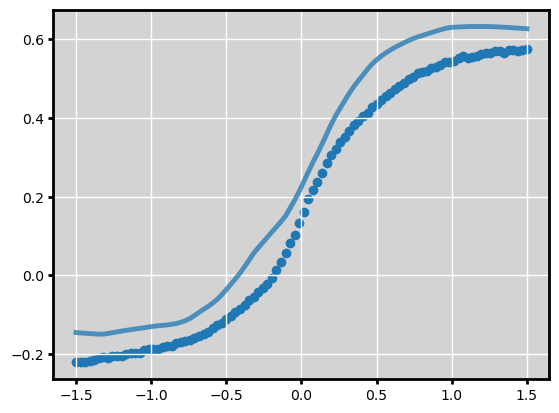

In [8]:
in_features = 8
out_features = 1
hidden_dim = 90
num_layers = 5

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)

state_dict = torch.load(f="../../SM_num_layers=5_hd=90_0.pth", map_location=torch.device("cpu"))
model.load_state_dict(state_dict=state_dict)
model.eval()

sim_curve = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/test_folder/test_file_7001.npz")
print(sim_curve.files)
vs_ = torch.linspace(-1.5, 1.5, 50)

n = 100
vs = torch.linspace(-1.5, 1.5, n)

x = torch.tensor([0.0, 0.0, 0.5, -1.3, 0.7, -0.1, 0.8, 1.2])
control_volts = x.unsqueeze(0).repeat(n, 1)
control_volts[:, 1] = vs

out = model(control_volts)

plot_kwargs = {
    "lw": 3.5,
    "alpha": 0.75
}
plt.scatter(vs, sim_curve["current"])
plt.plot(vs, out.detach(), **plot_kwargs, zorder=3)
ax = plt.gca()
ax.grid(True)
ax.set_facecolor("lightgrey")
ax.xaxis.grid(color="w", lw=1.)
ax.yaxis.grid(color="w", lw=1.)
ax.xaxis.set_tick_params(width=2)
ax.yaxis.set_tick_params(width=2)
ax.spines[['top', 'bottom', 'right', 'left']].set_linewidth(2)